<a href="https://colab.research.google.com/github/scarlettlaw/thai-overseas-workers/blob/main/notebooks/01_extract_destination_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from urllib.request import urlretrieve

pdf_url = "https://raw.githubusercontent.com/scarlettlaw/thai-overseas-workers/main/data/raw/doe_thai_workers_by_destination_2025.pdf.pdf"
pdf_path = "/content/destination_2025.pdf"

urlretrieve(pdf_url, pdf_path)

print("PDF downloaded successfully!")
print("Saved as:", pdf_path)

PDF downloaded successfully!
Saved as: /content/destination_2025.pdf


In [ ]:
!pip -q install pdfplumber

import pdfplumber

with pdfplumber.open(pdf_path) as pdf:
    print("Number of pages:", len(pdf.pages))

    first_page_text = pdf.pages[0].extract_text()

    print("\nFirst page preview:\n")
    print(first_page_text[:2000])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 555.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 88.7 MB/s eta 0:00:00
Number of pages: 5

First page preview:

จ านวนคนหางานที่ได้รับอนุญาตให้เดินทางไปท างานต่างประเทศ
(จ าแนกตามประเทศ/ดินแดน และประเภทการเดินทาง) ยอดสรุปประจ าปี 2568 (มกราคม - ธันวาคม)
การแจ้ง กรมการ นายจ้าง นายจ้าง
บริษัทจัดหางานจัดส่ง แจ้งเดินทางกลับไปท างานในต่างประเทศ
5 วิธีเดินทาง การเดินทาง จัดหางาน พาลูกจ้าง ส่งลูกจ้าง
ประเทศ/ดินแดน
ด้วยตนเอง จัดส่ง ไปท างาน ไปฝึกงาน บจง บจร รวม Re-Entry VISA Re-Entry
รวม
รวม ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง ชาย หญิง
ทั่วประเทศ 69,646 55,9

In [ ]:
import re
import pandas as pd

records = []

number_pattern = r"[\d,]+|[-–—]"
row_pattern = re.compile(
    rf"^(.*?)\s+({number_pattern})\s+({number_pattern})\s+({number_pattern})(?:\s|$)"
)

def clean_number(value):
    if value in ["-", "–", "—"]:
        return 0
    return int(value.replace(",", ""))

with pdfplumber.open(pdf_path) as pdf:
    for page_number, page in enumerate(pdf.pages, start=1):
        page_text = page.extract_text() or ""

        for line in page_text.splitlines():
            match = row_pattern.match(line.strip())

            if match:
                records.append({
                    "destination_th": match.group(1).strip(),
                    "workers_total": clean_number(match.group(2)),
                    "workers_male": clean_number(match.group(3)),
                    "workers_female": clean_number(match.group(4)),
                    "page": page_number
                })

destination_raw = pd.DataFrame(records)

print("Number of rows extracted:", len(destination_raw))
display(destination_raw.head(15))

Number of rows extracted: 132


,destination_th,workers_total,workers_male,workers_female,page
0,ทั่วประเทศ,69646,55941,13705,1
1,รวมกลุ่มประเทศตะวันออกกลาง,21923,20464,1459,1
2,รัฐกาตาร์,297,213,84,1
3,รัฐคูเวต,270,223,47,1
4,รัฐสุลต่านโอมาน,11,8,3,1
5,รัฐอิสราเอล,20619,19538,1081,1
6,ราชอาณาจักรซาอุดีอาระเบีย,142,69,73,1
7,ราชอาณาจักรบาห์เรน,89,66,23,1
8,ราชอาณาจักรฮัชไมต์จอร์แดน,0,0,0,1
9,สหรัฐอาหรับเอมิเรตส์,423,324,99,1


In [ ]:
destination_2025 = destination_raw[
    (destination_raw["destination_th"] != "ทั่วประเทศ") &
    (~destination_raw["destination_th"].str.startswith("รวมกลุ่มประเทศ")) &
    (destination_raw["workers_total"] > 0)
].copy()

destination_2025["year"] = 2025

destination_2025 = destination_2025[
    [
        "year",
        "destination_th",
        "workers_total",
        "workers_male",
        "workers_female"
    ]
]

official_total = destination_raw.loc[
    destination_raw["destination_th"] == "ทั่วประเทศ",
    "workers_total"
].iloc[0]

calculated_total = destination_2025["workers_total"].sum()

print("Official national total:", official_total)
print("Sum of extracted countries:", calculated_total)
print("Difference:", official_total - calculated_total)

display(
    destination_2025
    .sort_values("workers_total", ascending=False)
    .head(15)
)

Official national total: 69646
Sum of extracted countries: 69646
Difference: 0


,year,destination_th,workers_total,workers_male,workers_female
5,2025,รัฐอิสราเอล,20619,19538,1081
41,2025,ไต้หวัน,18108,15480,2628
40,2025,ญปี่ ุ่น,5994,2898,3096
47,2025,สาธารณรัฐเกาหลี,5921,5015,906
91,2025,สาธารณรัฐฟินแลนด์,3044,2568,476
52,2025,สาธารณรัฐประชาธิปไตยประชาชนลาว,1958,1811,147
117,2025,สหรัฐอเมริกา,1640,620,1020
57,2025,สาธารณรัฐสิงคโปร์,1273,929,344
64,2025,ฮ่องกง,1024,219,805
76,2025,ราชอาณาจักรสวีเดน,1012,685,327


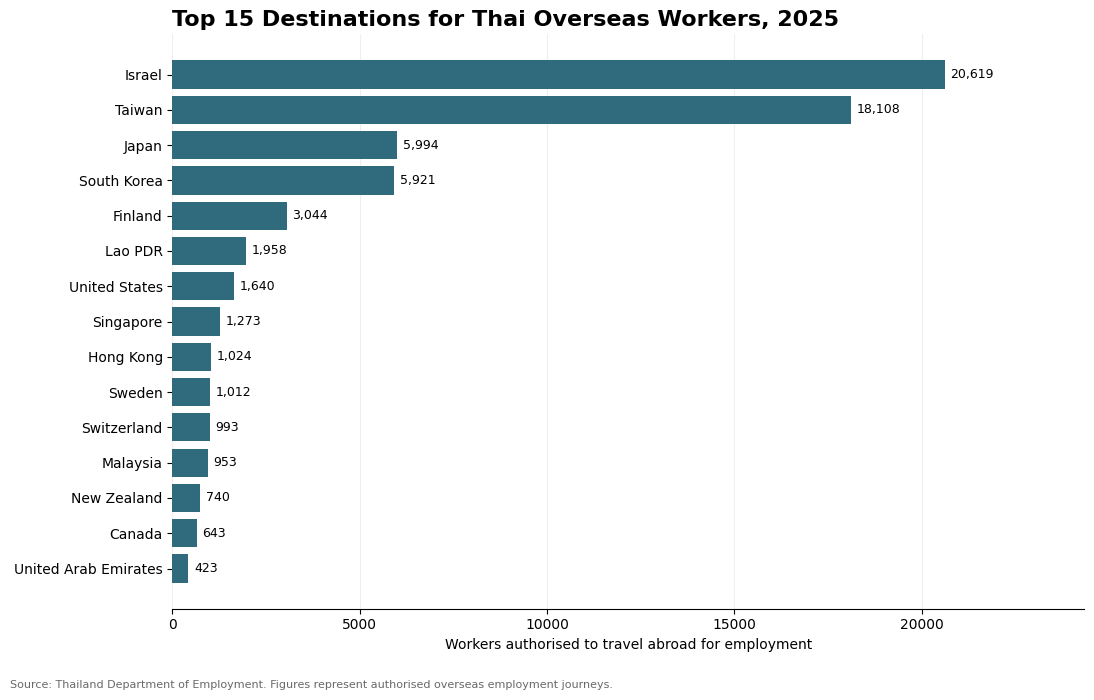

Chart saved as: /content/top_15_destinations_2025.png


In [11]:
import matplotlib.pyplot as plt

country_name_map = {
    "รัฐอิสราเอล": "Israel",
    "ไต้หวัน": "Taiwan",
    "ญี่ปุ่น": "Japan",
    "สาธารณรัฐเกาหลี": "South Korea",
    "สาธารณรัฐฟินแลนด์": "Finland",
    "สาธารณรัฐประชาธิปไตยประชาชนลาว": "Lao PDR",
    "สหรัฐอเมริกา": "United States",
    "สาธารณรัฐสิงคโปร์": "Singapore",
    "ฮ่องกง": "Hong Kong",
    "ราชอาณาจักรสวีเดน": "Sweden",
    "สมาพันธรัฐสวิส(สวิตเซอร์แลนด์)": "Switzerland",
    "มาเลเซีย": "Malaysia",
    "นิวซีแลนด์": "New Zealand",
    "แคนาดา": "Canada",
    "สหรัฐอาหรับเอมิเรตส์": "United Arab Emirates"
}

destination_2025["destination_en"] = (
    destination_2025["destination_th"]
    .map(country_name_map)
    .fillna(destination_2025["destination_th"])
)
# Correct the Japan row identified in the official 2025 data
destination_2025.loc[
    destination_2025["workers_total"] == 5994,
    "destination_en"
] = "Japan"

top_15 = (
    destination_2025
    .nlargest(15, "workers_total")
    .sort_values("workers_total")
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_15["destination_en"],
    top_15["workers_total"],
    color="#2F6B7C"
)

ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in top_15["workers_total"]],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 15 Destinations for Thai Overseas Workers, 2025",
    fontsize=16,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel("Workers authorised to travel abroad for employment")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

ax.set_xlim(0, top_15["workers_total"].max() * 1.18)

fig.text(
    0.01,
    0.01,
    "Source: Thailand Department of Employment. Figures represent authorised overseas employment journeys.",
    fontsize=8,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

chart_path = "/content/top_15_destinations_2025.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved as:", chart_path)